In [1]:
# =========================================================
# 1) IMPORTS
# =========================================================
import os
import glob

import duckdb
import pandas as pd
import pyarrow.parquet as pq

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)


In [2]:

# =========================================================
# 2) PATH TO YOUR 2025 FILES
# =========================================================
DATA_DIR = "data/2025"   # change this if needed

files = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))

print("Number of parquet files found:", len(files))
print()

for f in files:
    print(os.path.basename(f))

if len(files) == 0:
    raise FileNotFoundError(f"No parquet files found in: {DATA_DIR}")


Number of parquet files found: 11

yellow_tripdata_2025-01.parquet
yellow_tripdata_2025-02.parquet
yellow_tripdata_2025-03.parquet
yellow_tripdata_2025-04.parquet
yellow_tripdata_2025-05.parquet
yellow_tripdata_2025-06.parquet
yellow_tripdata_2025-07.parquet
yellow_tripdata_2025-08.parquet
yellow_tripdata_2025-09.parquet
yellow_tripdata_2025-10.parquet
yellow_tripdata_2025-11.parquet


In [3]:

# =========================================================
# 3) BASIC FILE-LEVEL INSPECTION
# =========================================================
file_info = []

for f in files:
    pf = pq.ParquetFile(f)
    cols = pf.schema_arrow.names
    
    file_info.append({
        "file": os.path.basename(f),
        "num_rows": pf.metadata.num_rows,
        "num_columns": len(cols),
        "columns": cols
    })

file_info_df = pd.DataFrame(file_info)

print("\n===== FILE SUMMARY =====")
display(file_info_df[["file", "num_rows", "num_columns"]])

print("Total rows across all files:", f"{file_info_df['num_rows'].sum():,}")



===== FILE SUMMARY =====


,file,num_rows,num_columns
0,yellow_tripdata_2025-01.parquet,3475226,20
1,yellow_tripdata_2025-02.parquet,3577543,20
2,yellow_tripdata_2025-03.parquet,4145257,20
3,yellow_tripdata_2025-04.parquet,3970553,20
4,yellow_tripdata_2025-05.parquet,4591845,20
5,yellow_tripdata_2025-06.parquet,4322960,20
6,yellow_tripdata_2025-07.parquet,3898963,20
7,yellow_tripdata_2025-08.parquet,3574091,20
8,yellow_tripdata_2025-09.parquet,4251015,20
9,yellow_tripdata_2025-10.parquet,4428699,20


Total rows across all files: 44,417,596


In [4]:

# =========================================================
# 4) PRINT COLUMNS OF EACH FILE
# =========================================================
print("\n===== COLUMNS IN EACH FILE =====\n")

for row in file_info:
    print(f"--- {row['file']} ---")
    for col in row["columns"]:
        print(col)
    print()



===== COLUMNS IN EACH FILE =====

--- yellow_tripdata_2025-01.parquet ---
VendorID
tpep_pickup_datetime
tpep_dropoff_datetime
passenger_count
trip_distance
RatecodeID
store_and_fwd_flag
PULocationID
DOLocationID
payment_type
fare_amount
extra
mta_tax
tip_amount
tolls_amount
improvement_surcharge
total_amount
congestion_surcharge
Airport_fee
cbd_congestion_fee

--- yellow_tripdata_2025-02.parquet ---
VendorID
tpep_pickup_datetime
tpep_dropoff_datetime
passenger_count
trip_distance
RatecodeID
store_and_fwd_flag
PULocationID
DOLocationID
payment_type
fare_amount
extra
mta_tax
tip_amount
tolls_amount
improvement_surcharge
total_amount
congestion_surcharge
Airport_fee
cbd_congestion_fee

--- yellow_tripdata_2025-03.parquet ---
VendorID
tpep_pickup_datetime
tpep_dropoff_datetime
passenger_count
trip_distance
RatecodeID
store_and_fwd_flag
PULocationID
DOLocationID
payment_type
fare_amount
extra
mta_tax
tip_amount
tolls_amount
improvement_surcharge
total_amount
congestion_surcharge
Airport_fe

In [5]:
# =========================================================
# 5) COMPARE COLUMNS ACROSS FILES
# =========================================================
column_sets = [set(row["columns"]) for row in file_info]

common_columns = set.intersection(*column_sets)
all_columns = set.union(*column_sets)

print("===== COMMON COLUMNS ACROSS ALL FILES =====")
for col in sorted(common_columns):
    print(col)

print("\nNumber of common columns:", len(common_columns))

print("\n===== ALL DISTINCT COLUMNS SEEN IN AT LEAST ONE FILE =====")
for col in sorted(all_columns):
    print(col)

print("\nNumber of distinct columns overall:", len(all_columns))


===== COMMON COLUMNS ACROSS ALL FILES =====
Airport_fee
DOLocationID
PULocationID
RatecodeID
VendorID
cbd_congestion_fee
congestion_surcharge
extra
fare_amount
improvement_surcharge
mta_tax
passenger_count
payment_type
store_and_fwd_flag
tip_amount
tolls_amount
total_amount
tpep_dropoff_datetime
tpep_pickup_datetime
trip_distance

Number of common columns: 20

===== ALL DISTINCT COLUMNS SEEN IN AT LEAST ONE FILE =====
Airport_fee
DOLocationID
PULocationID
RatecodeID
VendorID
cbd_congestion_fee
congestion_surcharge
extra
fare_amount
improvement_surcharge
mta_tax
passenger_count
payment_type
store_and_fwd_flag
tip_amount
tolls_amount
total_amount
tpep_dropoff_datetime
tpep_pickup_datetime
trip_distance

Number of distinct columns overall: 20


In [6]:

# =========================================================
# 6) SHOW COLUMNS THAT ARE NOT PRESENT IN EVERY FILE
# =========================================================
print("\n===== COLUMNS NOT CONSISTENT ACROSS FILES =====\n")

inconsistent_found = False

for col in sorted(all_columns):
    present_in = [row["file"] for row in file_info if col in set(row["columns"])]
    if len(present_in) != len(file_info):
        inconsistent_found = True
        print(f"Column: {col}")
        print("Present in:")
        for fname in present_in:
            print("  ", fname)
        print()

if not inconsistent_found:
    print("All files have the same columns.")



===== COLUMNS NOT CONSISTENT ACROSS FILES =====

All files have the same columns.


In [7]:
# =========================================================
# 7) DUCKDB VIEW OVER ALL FILES
# =========================================================
con = duckdb.connect()

file_list_sql = ", ".join([f"'{f}'" for f in files])

con.execute(f"""
    CREATE OR REPLACE VIEW trips_2025 AS
    SELECT *
    FROM read_parquet([{file_list_sql}], union_by_name=True)
""")


In [8]:

# =========================================================
# 8) PRINT COLUMN NAMES FROM THE COMBINED VIEW
# =========================================================
schema_df = con.execute("DESCRIBE trips_2025").df()

print("\n===== COLUMNS IN COMBINED DATASET =====")
display(schema_df)



===== COLUMNS IN COMBINED DATASET =====


,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,BIGINT,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,RatecodeID,BIGINT,YES,None,None,None
6,store_and_fwd_flag,VARCHAR,YES,None,None,None
7,PULocationID,INTEGER,YES,None,None,None
8,DOLocationID,INTEGER,YES,None,None,None
9,payment_type,BIGINT,YES,None,None,None


In [9]:

# =========================================================
# 9) SHAPE OF THE COMBINED DATASET
# =========================================================
n_rows = con.execute("SELECT COUNT(*) FROM trips_2025").fetchone()[0]
n_cols = schema_df.shape[0]

print("Combined shape:")
print("Rows:", f"{n_rows:,}")
print("Columns:", n_cols)


Combined shape:
Rows: 44,417,596
Columns: 20


In [10]:

# =========================================================
# 10) FIRST 10 ROWS
# =========================================================
print("\n===== FIRST 10 ROWS =====")
sample_df = con.execute("SELECT * FROM trips_2025 LIMIT 10").df()
display(sample_df)



===== FIRST 10 ROWS =====


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1,1.60,1,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1,0.50,1,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1,0.60,1,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3,0.52,1,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3,0.66,1,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0
5,2,2025-01-01 00:48:24,2025-01-01 01:08:26,2,2.63,1,N,239,68,2,19.1,1.0,0.5,0.00,0.0,1.0,24.10,2.5,0.0,0.0
6,1,2025-01-01 00:14:47,2025-01-01 00:16:15,0,0.40,1,N,170,170,1,4.4,3.5,0.5,2.35,0.0,1.0,11.75,2.5,0.0,0.0
7,1,2025-01-01 00:39:27,2025-01-01 00:51:51,0,1.60,1,N,234,148,1,12.1,3.5,0.5,2.00,0.0,1.0,19.10,2.5,0.0,0.0
8,1,2025-01-01 00:53:43,2025-01-01 01:13:23,0,2.80,1,N,148,170,1,19.1,3.5,0.5,3.00,0.0,1.0,27.10,2.5,0.0,0.0
9,2,2025-01-01 00:00:02,2025-01-01 00:09:36,1,1.71,1,N,237,262,2,11.4,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.0,0.0


In [11]:

# =========================================================
# 11) FIRST 5 ROWS OF EACH FILE
# =========================================================
print("\n===== FIRST 5 ROWS OF EACH FILE =====\n")

for f in files:
    print(f"--- {os.path.basename(f)} ---")
    temp_df = duckdb.query(f"SELECT * FROM read_parquet('{f}') LIMIT 5").df()
    display(temp_df)



===== FIRST 5 ROWS OF EACH FILE =====

--- yellow_tripdata_2025-01.parquet ---


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1,1.60,1,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1,0.50,1,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1,0.60,1,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3,0.52,1,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3,0.66,1,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


--- yellow_tripdata_2025-02.parquet ---


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2025-02-01 00:12:18,2025-02-01 00:32:33,3,3.12,1,N,246,79,1,19.8,1.00,0.5,5.11,0.0,1.0,30.66,2.5,0.0,0.75
1,2,2025-02-01 00:40:04,2025-02-01 00:49:15,1,1.40,1,N,114,79,1,10.0,1.00,0.5,3.15,0.0,1.0,18.90,2.5,0.0,0.75
2,1,2025-02-01 00:06:09,2025-02-01 00:11:51,0,0.40,1,N,211,144,1,6.5,4.25,0.5,1.00,0.0,1.0,13.25,2.5,0.0,0.75
3,1,2025-02-01 00:15:13,2025-02-01 00:20:19,0,0.70,1,N,113,249,1,7.2,4.25,0.5,2.00,0.0,1.0,14.95,2.5,0.0,0.75
4,2,2025-02-01 00:02:52,2025-02-01 00:20:25,1,4.19,1,N,113,263,1,19.8,1.00,0.5,5.11,0.0,1.0,30.66,2.5,0.0,0.75


--- yellow_tripdata_2025-03.parquet ---


...

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2025-09-01 00:19:20,2025-09-01 00:45:17,1,9.92,1,N,138,114,1,42.9,6.0,0.5,10.73,0.0,1.0,66.13,2.5,1.75,0.75
1,2,2025-09-01 00:15:20,2025-09-01 00:26:08,2,6.82,1,N,93,157,1,26.8,1.0,0.5,5.86,0.0,1.0,35.16,0.0,0.00,0.00
2,2,2025-09-01 00:06:07,2025-09-01 00:22:23,1,3.95,1,N,68,13,1,19.8,1.0,0.5,5.11,0.0,1.0,30.66,2.5,0.00,0.75
3,2,2025-09-01 00:49:47,2025-09-01 01:04:49,1,3.14,1,N,234,87,1,17.7,1.0,0.5,3.52,0.0,1.0,26.97,2.5,0.00,0.75
4,2,2025-09-01 00:05:00,2025-09-01 00:15:32,6,2.81,1,N,230,151,1,14.9,1.0,0.5,4.13,0.0,1.0,24.78,2.5,0.00,0.75


--- yellow_tripdata_2025-10.parquet ---


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-10-01 00:15:32,2025-10-01 01:04:03,1,17.20,2,N,132,107,1,70.0,5.00,0.5,0.00,6.94,1.0,83.44,2.5,1.75,0.75
1,7,2025-10-01 00:00:08,2025-10-01 00:00:08,1,5.00,1,N,107,225,1,28.2,0.00,0.5,8.49,0.00,1.0,42.44,2.5,0.00,0.75
2,2,2025-10-01 00:08:54,2025-10-01 00:14:44,1,2.75,1,N,263,229,1,12.8,1.00,0.5,3.71,0.00,1.0,22.26,2.5,0.00,0.75
3,1,2025-10-01 00:58:48,2025-10-01 01:04:40,1,1.30,1,N,211,231,2,7.9,4.25,0.5,0.00,0.00,1.0,13.65,2.5,0.00,0.75
4,2,2025-10-01 00:39:51,2025-10-01 00:49:40,1,2.88,1,N,230,151,1,14.2,1.00,0.5,3.99,0.00,1.0,23.94,2.5,0.00,0.75


--- yellow_tripdata_2025-11.parquet ---


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,7,2025-11-01 00:13:25,2025-11-01 00:13:25,1,1.68,1,N,43,186,1,14.9,0.00,0.5,1.50,0.00,1.0,22.15,2.5,0.00,0.75
1,2,2025-11-01 00:49:07,2025-11-01 01:01:22,1,2.28,1,N,142,237,1,14.2,1.00,0.5,4.99,0.00,1.0,24.94,2.5,0.00,0.75
2,1,2025-11-01 00:07:19,2025-11-01 00:20:41,0,2.70,1,N,163,238,1,15.6,4.25,0.5,4.27,0.00,1.0,25.62,2.5,0.00,0.75
3,2,2025-11-01 00:00:00,2025-11-01 01:01:03,3,12.87,1,N,138,261,1,66.7,6.00,0.5,0.00,6.94,1.0,86.14,2.5,1.75,0.75
4,1,2025-11-01 00:18:50,2025-11-01 00:49:32,0,8.40,1,N,138,37,2,39.4,7.75,0.5,0.00,0.00,1.0,48.65,0.0,1.75,0.00


In [12]:

# =========================================================
# 12) OPTIONAL: COLUMN TYPES ONLY
# =========================================================
print("\n===== COLUMN TYPES =====")
display(schema_df[["column_name", "column_type"]])


===== COLUMN TYPES =====


,column_name,column_type
0,VendorID,INTEGER
1,tpep_pickup_datetime,TIMESTAMP
2,tpep_dropoff_datetime,TIMESTAMP
3,passenger_count,BIGINT
4,trip_distance,DOUBLE
5,RatecodeID,BIGINT
6,store_and_fwd_flag,VARCHAR
7,PULocationID,INTEGER
8,DOLocationID,INTEGER
9,payment_type,BIGINT


## Dataset Columns Explanation

### 1. Identifiers and Metadata

**VendorID (integer)**  
Identifier of the taxi company providing the trip. Mainly useful for filtering or comparing providers.

**RatecodeID (integer)**  
Indicates the type of fare applied:
- 1: Standard rate  
- 2: JFK flat fare  

---

### 2. Temporal Features

**tpep_pickup_datetime (timestamp)**  
**tpep_dropoff_datetime (timestamp)**  

Start and end time of each trip. These are central for analysis:
- Hourly patterns (traffic peaks)
- Daily patterns (weekday vs weekend)
- Monthly trends (seasonality)

---

### 3. Trip Characteristics

**passenger_count (integer)**  
Number of passengers. Can contain inconsistent values (e.g. 0).

**trip_distance (float)**  
Distance of the trip (in miles).  
Very important variable, typically highly skewed (many short trips).

---

### 4. Location Data

**PULocationID (integer)** → pickup zone  
**DOLocationID (integer)** → dropoff zone  

These correspond to NYC taxi zones and allow spatial analysis.

---

### 5. Payment Information

**payment_type (integer)**  
Payment method:
- 1: Credit card  
- 2: Cash  

---

### 6. Fare Components

**fare_amount (float)** → base fare  
**tip_amount (float)** → tip  
**total_amount (float)** → total paid  

Other components:
- extra  
- mta_tax  
- tolls_amount  
- improvement_surcharge  
- congestion_surcharge  
- Airport_fee  
- cbd_congestion_fee  

These allow detailed pricing analysis.

---

### 7. Technical Variable

**store_and_fwd_flag (string)**  
Indicates if the trip was stored before being sent.  
Not useful for analysis.

---

### Key Variables for Analysis

The most relevant variables for this project are:

- `tpep_pickup_datetime`
- `trip_distance`
- `total_amount`
- `tip_amount`
- `passenger_count`
- `PULocationID`
- `DOLocationID`

# BASIC ANALYSIS

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_trips,avg_distance,median_distance,max_distance,avg_total,median_total,max_total,avg_tip,median_tip,avg_passengers
0,44417596,6.833365,1.85,397994.37,26.524228,21.05,863380.37,2.843614,2.02,1.29382


Clean view created
Time features added


,month,n_trips
0,1,3325344
1,2,3426082
2,3,3977244
3,4,3810814
4,5,4347710
5,6,4118352
6,7,3703033
7,8,3386057
8,9,4052856
9,10,4203295


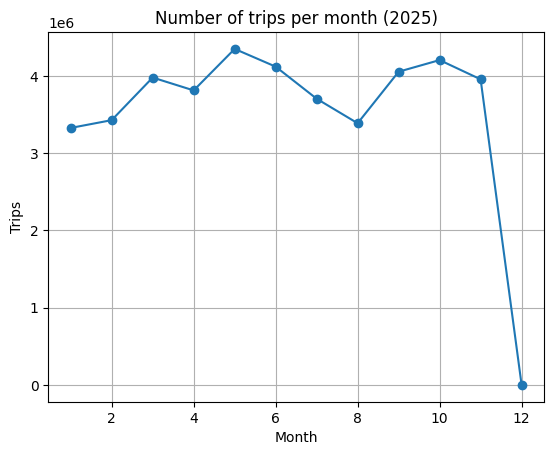

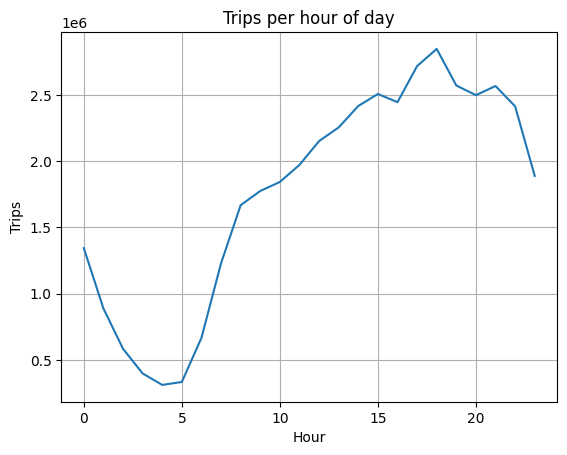

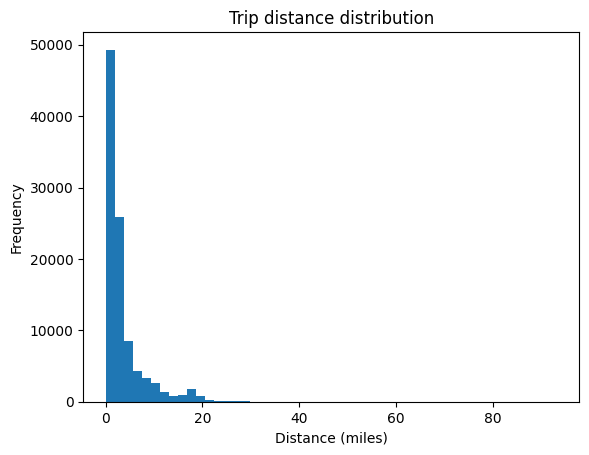

In [14]:
# =========================================================
# BASIC ANALYSIS
# =========================================================

# 1) BASIC STATS (FAST WITH DUCKDB)
stats = con.execute("""
SELECT
    COUNT(*) as n_trips,
    
    AVG(trip_distance) as avg_distance,
    MEDIAN(trip_distance) as median_distance,
    MAX(trip_distance) as max_distance,
    
    AVG(total_amount) as avg_total,
    MEDIAN(total_amount) as median_total,
    MAX(total_amount) as max_total,
    
    AVG(tip_amount) as avg_tip,
    MEDIAN(tip_amount) as median_tip,
    
    AVG(passenger_count) as avg_passengers
FROM trips_2025
""").df()

display(stats)


# =========================================================
# 2) QUICK DATA CLEANING (LIGHT)
# =========================================================

clean_view_query = """
CREATE OR REPLACE VIEW trips_clean AS
SELECT *
FROM trips_2025
WHERE 
    trip_distance > 0
    AND total_amount > 0
    AND trip_distance < 100
    AND total_amount < 500
"""

con.execute(clean_view_query)

print("Clean view created")


# =========================================================
# 3) ADD TIME FEATURES
# =========================================================

time_view_query = """
CREATE OR REPLACE VIEW trips_time AS
SELECT *,
    EXTRACT(month FROM tpep_pickup_datetime) AS month,
    EXTRACT(hour FROM tpep_pickup_datetime) AS hour,
    EXTRACT(dayofweek FROM tpep_pickup_datetime) AS weekday
FROM trips_clean
"""

con.execute(time_view_query)

print("Time features added")


# =========================================================
# 4) TRIPS PER MONTH (MAIN SIGNAL)
# =========================================================

df_month = con.execute("""
SELECT month, COUNT(*) as n_trips
FROM trips_time
GROUP BY month
ORDER BY month
""").df()

display(df_month)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_month["month"], df_month["n_trips"], marker="o")
plt.title("Number of trips per month (2025)")
plt.xlabel("Month")
plt.ylabel("Trips")
plt.grid()
plt.show()


# =========================================================
# 5) TRIPS PER HOUR
# =========================================================

df_hour = con.execute("""
SELECT hour, COUNT(*) as n_trips
FROM trips_time
GROUP BY hour
ORDER BY hour
""").df()

plt.figure()
plt.plot(df_hour["hour"], df_hour["n_trips"])
plt.title("Trips per hour of day")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.grid()
plt.show()


# =========================================================
# 6) DISTANCE DISTRIBUTION (SAMPLED)
# =========================================================

df_sample = con.execute("""
SELECT trip_distance
FROM trips_time
USING SAMPLE 100000
""").df()

plt.figure()
plt.hist(df_sample["trip_distance"], bins=50)
plt.title("Trip distance distribution")
plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")
plt.show()